# Assignment 2: Feedforward Neural Networks

## Programming Question 1: Implementing Deep FNN
Through this assignment you learn how to use `torch.nn` module of torch to implement a neural network in only few lines of code.

We first import all required packages.

In [1]:
# We import torch and the nn module
import torch
import torch.nn as nn

# We import NumPy and tqdm
import numpy as np
from tqdm import tqdm

# We need few items from Scikit-Learn
import sklearn.datasets as DataSets
from sklearn.model_selection import train_test_split

# Also we need to plot few curves
import matplotlib.pyplot as plt

### Data Splitting: Make Training Mini-Batches

In [2]:
dataset = DataSets.make_classification(n_samples = 10000
                                       , n_features = 20
                                       , n_informative=5
                                       , n_redundant=15
                                       , random_state=1)
X, v = dataset

# Verify dimensions of X and v
print("Shape of X:", X.shape)
print("Shape of v:", v.shape)

# Print the first data point and its label
print("First data point of X:", X[0])
print("Label of first data point:", v[0])

# Specify the data type
print("Data Type of X:", type(X))
print("Data Type of v:", type(v))

Shape of X: (10000, 20)
Shape of v: (10000,)
First data point of X: [ 2.71294902  0.36835788 -3.80071947  1.01325651  2.21353836 -1.03984687
  0.15280907 -1.22478592 -1.34564992 -2.13232466 -3.79654552 -0.83454172
 -4.22074562 -0.15507548 -0.90781521  1.00672718 -0.15219737  2.51314894
  1.77917975  3.08728753]
Label of first data point: 1
Data Type of X: <class 'numpy.ndarray'>
Data Type of v: <class 'numpy.ndarray'>


Below you can implement the function

In [3]:
def data_splitter(X, v, batch_size, train_size):
    '''
    X is list of data-points
    v is list of labels
    train_size is the fraction of data-points used for training
    '''
    X_train, X_test, v_train, v_test = train_test_split(X, v
        , train_size= train_size
        , shuffle = True
        )
    X_train = torch.tensor(X_train,dtype=torch.float32)
    v_train = torch.tensor(v_train,dtype=torch.float32).reshape(-1,1)
    X_test = torch.tensor(X_test, dtype=torch.float32)
    v_test = torch.tensor(v_test, dtype=torch.float32).reshape(-1, 1)

    batch_indx = torch.arange(0, len(X_train), batch_size).tolist()

    return X_train, v_train, X_test, v_test, batch_indx

In [4]:
# Create two independent datasets
# Dataset 1
X1, v1 = DataSets.make_classification(n_samples=10000, n_features=20, n_informative=5, n_redundant=15, random_state=41)
X2, v2 = DataSets.make_classification(n_samples=10000, n_features=20, n_informative=5, n_redundant=15, random_state=78)


# Call the data_splitter function with the first dataset
X_train_1, v_train_1, X_test_1, v_test_1, batch_indx_1 = data_splitter(X1, v1, 128, 0.83)
X_train_2, v_train_2, X_test_2, v_test_2, batch_indx_2 = data_splitter(X2, v2, 512, 0.76)

# Verifying the output
print("Instance 1:X_train shape:", X_train_1.shape)
print("Instance 1:v_train shape:", v_train_1.shape)
print("First 10 batch start indices for Instance 1:", batch_indx_1[:10])

print("")
print("Instance 2: X_train shape:", X_train_2.shape)
print("Instance 2: v_train shape:", v_train_2.shape)
print("First 10 batch start indices for Instance 2:", batch_indx_2[:10])


Instance 1:X_train shape: torch.Size([8300, 20])
Instance 1:v_train shape: torch.Size([8300, 1])
First 10 batch start indices for Instance 1: [0, 128, 256, 384, 512, 640, 768, 896, 1024, 1152]

Instance 2: X_train shape: torch.Size([7600, 20])
Instance 2: v_train shape: torch.Size([7600, 1])
First 10 batch start indices for Instance 2: [0, 512, 1024, 1536, 2048, 2560, 3072, 3584, 4096, 4608]


### Basic Classes

For this task you can use `nn.Layer()`. You mainly need to complete the following `class`.

In [5]:
class myClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        self.layer1 = nn.Linear(in_features=20, out_features=64) # input 20 features
        self.active1 = nn.ReLU()

        self.layer2 = nn.Linear(in_features=64, out_features=32)
        self.active2 = nn.ReLU()

        self.output = nn.Linear(in_features=32, out_features=1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.active1(self.layer1(x))
        x = self.active2(self.layer2(x))
        x = self.sigmoid(self.output(x))
        return x

In [6]:
#verify
verify_model = myClassifier()

# Take the first data point and its label from verify model before
x_first = X_train_1[0].unsqueeze(0)
v_first = v_train_1[0].clone().detach()

# Forward pass
y_first = verify_model.forward(x_first)  # Model's prediction

# Print the results
print("Model's output (predicted):", y_first.item())
print("Label:", v_first.item())

Model's output (predicted): 0.5231620073318481
Label: 1.0


### Backpropagation
We now learn how we can use the autograd of PyTorch to implement backpropagation. Simply complete the following code and run it to see how autograd works.

In [7]:
# first, instantiate the model
myModel = myClassifier()

# now, define the loss
loss_fn = nn.BCELoss()

# split the dataset via function data_splitter()
batch_size = 64
train_size = 0.8
X_train, v_train, X_test, v_test, batch_indx = data_splitter(X, v, batch_size, train_size)

# take a sample point from training dataset
x = X_train[0].unsqueeze(0)
v = v_train[0].unsqueeze(0)

# forward pass
y = myModel.forward(x)
Loss = loss_fn(y, v)

print("Gradient before backward pass:", myModel.output.bias.grad)

# backward pass
Loss.backward()

print("Gradient after backward pass:", myModel.output.bias.grad)

Gradient before backward pass: None
Gradient after backward pass: tensor([-0.3485])


We can now access the computed gradient of the loss with respect to the output bias using the following code.

In [8]:
myModel.output.bias.grad

tensor([-0.3485])

### Optimizer
We can further define the optimizer for our model as follows:

In [9]:
# first, instantiate the model
myModel = myClassifier()

# now define the optimizer
optimizer = torch.optim.Adam(myModel.parameters()
                        , lr=0.0001 # this specifies the learning rate
                        )

### Implementing Training and Test Loop
Now that we have all the components, we can simply implement the training loop. Complete the following code to get the training done.

In [10]:
def training_loop(model):
    # define the loss and optimizer
    loss_fn = nn.BCELoss() # binary cross-entropy
    optimizer =  torch.optim.Adam(model.parameters(), lr=0.0001)  # Adam optimizer

    # set the training parameters
    n_epochs = 300   # number of epochs
    batch_size = 40  # batch size

    # specify training and test datasets and the batch indices
    # use data_splitter() and X, v are generated by Scikit-Learn
    X_train, v_train, X_test, v_test, batch_indx =data_splitter(X, v, batch_size, train_size=0.8)

    # make empty list to save training and test risk
    train_risk = []
    test_risk = []

    # training loop

    # we visualize the training progress via tqdm
    with tqdm(range(n_epochs), unit="epoch") as epoch_bar:
        epoch_bar.set_description("training loop")
        for epoch in epoch_bar:

            # tell pytorch that you start training
            model.train()

            for indx in batch_indx:
                # Take a batch of samples
                X_batch = X_train[indx: indx + batch_size]
                v_batch = v_train[indx: indx + batch_size]

                # Pass forward the mini-batch
                y_batch = model.forward(X_batch)
                # compute the loss
                loss =  loss_fn(y_batch, v_batch)

                # backward pass
                # first make gradient zero
                optimizer.zero_grad()
                # then, compute the gradient of loss
                loss.backward()

                # now update weights by one optimization step
                optimizer.step()

            # we are done with one epoch
            # we now evaluate training and test risks
            # first we tell pytorch we are doing evaluation
            model.eval()

            # now we evaluate the training risk
            y_train = model.forward(X_train)
            CE_train = loss_fn(y_train, v_train)
            train_risk.append(CE_train.item())

            # then we evaluate the test risk
            y_test = model.forward(X_test)
            CE_test = loss_fn(y_test, v_test)
            test_risk.append(CE_test.item())
        return train_risk, test_risk

We can now try training our model by passing the model to the training loop. Complete the following code to train the model and plot the learning curves.

training loop: 100%|██████████| 300/300 [00:51<00:00,  5.84epoch/s]


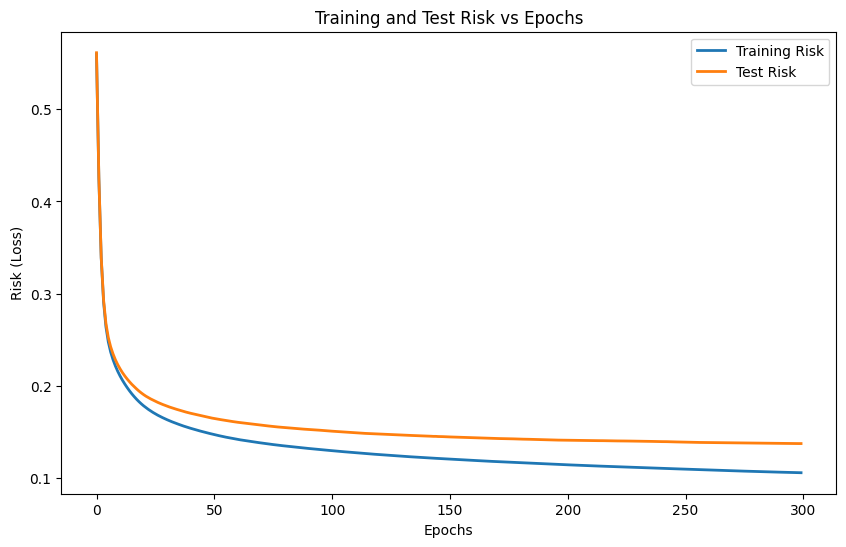

In [13]:
#init the model and train the model
myModel = myClassifier()
dataset = DataSets.make_classification(n_samples = 10000
                                       , n_features = 20
                                       , n_informative=5
                                       , n_redundant=15
                                       , random_state=1)
X, v = dataset
train_risk, test_risk = training_loop(myModel)

# Step 3: Plot the training and test risks
plt.figure(figsize=(10, 6))
plt.plot(train_risk, label="Training Risk", linewidth=2)
plt.plot(test_risk, label="Test Risk", linewidth=2)
plt.xlabel("Epochs")
plt.ylabel("Risk (Loss)")
plt.title("Training and Test Risk vs Epochs")
plt.legend()
plt.show()

## Programming Question 2: MNIST Dataset
We play around a bit with the datasets in PyTorch.

In [14]:
import torch
import torchvision.datasets as DS
import torchvision.transforms as transform

Import the MNIST dataset by running the code below.

In [15]:
mnist = DS.MNIST('./data',train=True,transform=transform.ToTensor(),download=True)

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:00<00:00, 35.6MB/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 1.07MB/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:00<00:00, 10.8MB/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 3.99MB/s]

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



In [16]:
#1 Use the command len() to check the length of object mnist
print("Length of MNIST dataset:", len(mnist))


Length of MNIST dataset: 60000


In [17]:
#2 Read the first tuple in mnist and specify its pixel tensor and label.
first_image, first_label = mnist[0]
print("Shape of first image:", first_image.shape)
print("Label of first image:", first_label)

Shape of first image: torch.Size([1, 28, 28])
Label of first image: 5


In [18]:
#3 Use the method .reshape() to reshape the pixel tensors into pixel vectors.
first_image_vector = first_image.reshape(784)
print("Shape of first image as vector:", first_image_vector.shape)  # Should print [784]

Shape of first image as vector: torch.Size([784])


We now build a function `myBatcher()` which gets the batch size as the input and returns a list containing multiple batches.

In [19]:
def myBatcher(batch_size):
    batch_list = []
    num_batches = int(len(mnist) / batch_size)

    for j in range(num_batches):
        batch_x = torch.zeros(batch_size,784)
        batch_v = torch.zeros(batch_size)
        for i in range(batch_size):
            data_point, label = mnist[j * batch_size + i]
            batch_x[i] = data_point.view(-1)  # Flatten and store the image
            batch_v[i] = label  # Store the label

        batch = (batch_x,batch_v)
        batch_list.append(batch)
    return batch_list

Let's try the implemented function

In [20]:
batch_list = myBatcher(100)
# Print labels of the first and third mini-batches

print("Labels of the first mini-batch: ",batch_list[0][1])  # Labels of the first mini-batch
print("Labels of the third mini-batch: ",batch_list[2][1])  # Labels of the third mini-batch

Labels of the first mini-batch:  tensor([5., 0., 4., 1., 9., 2., 1., 3., 1., 4., 3., 5., 3., 6., 1., 7., 2., 8.,
        6., 9., 4., 0., 9., 1., 1., 2., 4., 3., 2., 7., 3., 8., 6., 9., 0., 5.,
        6., 0., 7., 6., 1., 8., 7., 9., 3., 9., 8., 5., 9., 3., 3., 0., 7., 4.,
        9., 8., 0., 9., 4., 1., 4., 4., 6., 0., 4., 5., 6., 1., 0., 0., 1., 7.,
        1., 6., 3., 0., 2., 1., 1., 7., 9., 0., 2., 6., 7., 8., 3., 9., 0., 4.,
        6., 7., 4., 6., 8., 0., 7., 8., 3., 1.])
Labels of the third mini-batch:  tensor([1., 1., 8., 3., 6., 1., 0., 3., 1., 0., 0., 1., 7., 2., 7., 3., 0., 4.,
        6., 5., 2., 6., 4., 7., 1., 8., 9., 9., 3., 0., 7., 1., 0., 2., 0., 3.,
        5., 4., 6., 5., 8., 6., 3., 7., 5., 8., 0., 9., 1., 0., 3., 1., 2., 2.,
        3., 3., 6., 4., 7., 5., 0., 6., 2., 7., 9., 8., 5., 9., 2., 1., 1., 4.,
        4., 5., 6., 4., 1., 2., 5., 3., 9., 3., 9., 0., 5., 9., 6., 5., 7., 4.,
        1., 3., 4., 0., 4., 8., 0., 4., 3., 6.])
